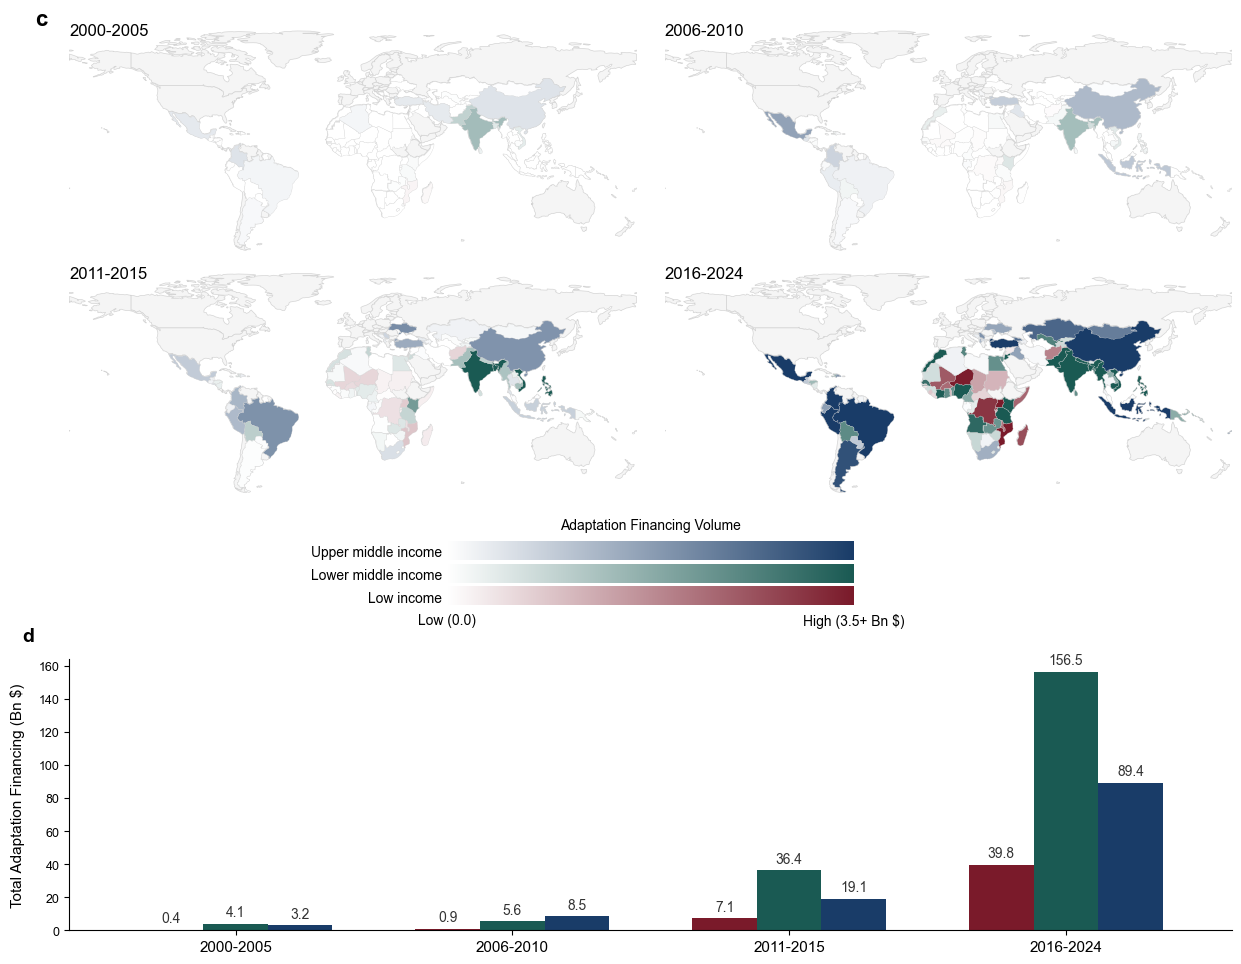

In [4]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.gridspec as gridspec
import numpy as np
from shapely.ops import unary_union
from mpl_toolkits.axes_grid1.inset_locator import inset_axes 

# ==========================================
# 0. 全局学术风格格式设置
# ==========================================
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'Helvetica', 'DejaVu Sans'],
    'pdf.fonttype': 42,
    'ps.fonttype': 42,
    'axes.linewidth': 0.8,
    'axes.labelsize': 10,
    'axes.titlesize': 11,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
    'legend.fontsize': 9,
    'legend.frameon': False,
    'xtick.direction': 'out',
    'ytick.direction': 'out',
    'xtick.major.width': 0.8,
    'ytick.major.width': 0.8
})

# ==========================================
# 1. 数据清洗与准备
# ==========================================
df = pd.read_csv('../regression_panel_with_gravity_IV_IncGroup_control.csv')
df['iso3'] = df['iso3'].str.strip()

# 剔除 High income 国家
df = df[df['Income group'] != 'High income'].copy()

# 划分年份阶段
bins = [1999, 2005, 2010, 2015, 2024]
labels = ['2000-2005', '2006-2010', '2011-2015', '2016-2024']
df['Period'] = pd.cut(df['year'], bins=bins, labels=labels)

# 汇总底部柱状图数据
trend_df = df.groupby(['Period', 'Income group'], observed=True)['Total_Adaptation_Finance'].sum().unstack()
income_order = ['Low income', 'Lower middle income', 'Upper middle income']
trend_df = trend_df[income_order]

# ==========================================
# 2. 地图几何体预加载与合并
# ==========================================
world_base = gpd.read_file('../世界地图shp/ne_110m_admin_0_countries.shp')
# china_mainland = world_base[world_base['ADM0_A3'] == 'CHN']
# taiwan = world_base[world_base['ADM0_A3'] == 'TWN']

# if not china_mainland.empty and not taiwan.empty:
#     combined_geom = unary_union([china_mainland.geometry.iloc[0], taiwan.geometry.iloc[0]])
#     world_base.loc[world_base['ADM0_A3'] == 'CHN', 'geometry'] = combined_geom
#     world_base = world_base[world_base['ADM0_A3'] != 'TWN']

# ==========================================
# 3. 避免红绿的深沉学术配色 (CVD-Friendly Deep Palette)
# ==========================================
deep_colors = {
    'Low income': '#8C510A',          # 焦糖棕
    'Lower middle income': '#D6B656', # 砂金色
    'Upper middle income': '#35978F'  # 海波绿
}
deep_colors = {
    'Low income': '#5B2C6F',          # 深邃紫 (Deep Purple) - 替代原来的酒红
    'Lower middle income': '#B9770E', # 暗雅金/深橘 (Dark Gold) - 替代原来的黛绿
    'Upper middle income': '#1A5276'  # 深海蓝 (Deep Steel Blue) - 保持冷色调高对比
}
deep_colors = {
    'Low income': '#7A1A2A',          # 深酒红 (沉稳的红色)
    'Lower middle income': '#1A5A53', # 黛绿 / 深孔雀绿 (低调的冷绿)
    'Upper middle income': '#193C68'  # 深海蓝 (高对比度的藏蓝)
}
bivariate_schemes = {k: ['#FFFFFF', v] for k, v in deep_colors.items()}
cmaps = {k: mcolors.LinearSegmentedColormap.from_list(k, v) for k, v in bivariate_schemes.items()}

global_sums = df.groupby(['iso3', 'Period'], observed=True)['Total_Adaptation_Finance'].sum()
vmin = 0 
vmax = global_sums.quantile(0.95) 
norm = mcolors.Normalize(vmin=vmin, vmax=vmax)

# ==========================================
# 4. 组装高级版式 (核心修改区：双 GridSpec 布局)
# ==========================================
# 稍微压缩整体高度，让版面更紧凑
fig = plt.figure(figsize=(15, 10)) 

# --- 修改重点 ---
# 1. 为地图专门创建“上部网格”。通过严格限制其占据的整体高度 (0.38到0.96)，
#    强行挤出地图的多余垂直白边，此时 hspace=0.02 就会真正生效。
gs_maps = gridspec.GridSpec(2, 2, top=0.96, bottom=0.48, hspace=0.02, wspace=0.05)

# 2. 为图例和条形图创建独立的“下部网格”。
#    这样它和地图的间距就不会互相干扰。
gs_bottom = gridspec.GridSpec(2, 1, top=0.45, bottom=0.05, height_ratios=[0.35, 0.8], hspace=0.05)

# 绑定地图坐标系到上部网格
axes_maps = [
    fig.add_subplot(gs_maps[0, 0]), fig.add_subplot(gs_maps[0, 1]),
    fig.add_subplot(gs_maps[1, 0]), fig.add_subplot(gs_maps[1, 1])
]

# 绑定图例和条形图到底部网格
ax_leg_base = fig.add_subplot(gs_bottom[0, 0])
ax_leg_base.set_axis_off() 

ax_bar = fig.add_subplot(gs_bottom[1, 0])

# ==========================================
# 5. 绘制上方地图阵列
# ==========================================
panel_labels = ['a', 'b', 'c', 'd']

for i, period in enumerate(labels):
    ax = axes_maps[i]
    ax.set_ylim(-60, 90) 
    ax.set_xlim(-180, 180)
    ax.set_axis_off()
    
    if i == 0:
        ax.text(-0.06, 1.05, 'c', transform=ax.transAxes, 
                fontsize=16, fontweight='bold', va='top', ha='left')
    
    ax.text(0.00, 0.99, period, transform=ax.transAxes, 
            fontsize=12, va='top', ha='left')
    
    world_base.plot(ax=ax, color='#f5f5f5', edgecolor='#d4d4d4', linewidth=0.5)
    
    df_period = df[df['Period'] == period]
    df_map = df_period.groupby('iso3').agg({
        'Total_Adaptation_Finance': 'sum',
        'Income group': 'first' 
    }).reset_index()
    
    if 'CHN' in df_map['iso3'].values:
        chn_val = df_map.loc[df_map['iso3'] == 'CHN', 'Total_Adaptation_Finance'].values[0]
        chn_inc = df_map.loc[df_map['iso3'] == 'CHN', 'Income group'].values[0]
        df_map.loc[df_map['iso3'] == 'TWN', ['Total_Adaptation_Finance', 'Income group']] = [chn_val, chn_inc]
        
    world = world_base.merge(df_map, left_on='ADM0_A3', right_on='iso3', how='left')
    
    for _, row in world.iterrows():
        group = row['Income group']
        val = row['Total_Adaptation_Finance']
        if pd.notnull(group) and pd.notnull(val) and group in cmaps:
            cmap = cmaps[group]
            intensity = np.clip(norm(val), 0, 1)
            gpd.GeoSeries([row.geometry]).plot(ax=ax, color=cmap(intensity), edgecolor='#d4d4d4', linewidth=0.2)

# ==========================================
# 6. 插入图例
# ==========================================
ax_leg = inset_axes(ax_leg_base, width="35%", height="60%", loc='upper center')

for i, group in enumerate(income_order):
    gradient = np.linspace(0, 1, 256).reshape(1, 256)
    ax_leg.imshow(gradient, extent=[0, 1, i, i+0.8], cmap=cmaps[group], aspect='auto')

ax_leg.set_ylim(-0.1, len(income_order))
ax_leg.set_yticks([i + 0.4 for i in range(len(income_order))])
ax_leg.set_yticklabels(income_order, fontsize=10)
ax_leg.set_xticks([0, 1])
ax_leg.set_xticklabels([f'Low ({vmin:.1f})', f'High ({vmax:.1f}+ Bn $)'], fontsize=10)

ax_leg.set_title('Adaptation Financing Volume', fontsize=10, pad=5)
for spine in ax_leg.spines.values(): 
    spine.set_visible(False)
ax_leg.tick_params(length=0)

# ==========================================
# 7. 绘制下方总量趋势图
# ==========================================
ax_bar.text(-0.03, 1.05, 'd', transform=ax_bar.transAxes, 
            fontsize=14, fontweight='bold', va='bottom', ha='right')

bar_colors = [deep_colors[g] for g in income_order]

trend_df.plot(kind='bar', ax=ax_bar, color=bar_colors, edgecolor='none', width=0.7, legend=False)

for container in ax_bar.containers:
    ax_bar.bar_label(container, fmt='%.1f', label_type='edge', fontsize=10, color='#333333', padding=3)

ax_bar.set_ylabel('Total Adaptation Financing (Bn $)', fontsize=11, labelpad=10)
ax_bar.set_xlabel('')
ax_bar.tick_params(axis='x', rotation=0, labelsize=11)
# ax_bar.grid(axis='y', linestyle='-', alpha=0.3, color='#AAAAAA', linewidth=0.8)

ax_bar.spines['top'].set_visible(False)
ax_bar.spines['right'].set_visible(False)

# ax_bar.legend(frameon=False, loc='upper left', fontsize=10)

# ==========================================
# 8. 导出与输出
# ==========================================
plt.savefig('Final/Fig.1c&d_Adaptation_Financing_DeepStyle.png', dpi=900, bbox_inches='tight', facecolor='white')

plt.show()